In [1]:
# Importing all required libraries for analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Connecting to MySQL and loading the supply chain data into a dataframe
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Shivaraj$2000",   # replace with your MySQL root password
    database="dataco_supply_chain"
)

df = pd.read_sql("SELECT * FROM supply_chain", conn)
conn.close()

print("Data loaded successfully!")
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Data loaded successfully!
Total rows: 180519
Total columns: 53


In [4]:
# Getting a first look at the data - shape, columns, data types
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (180519, 53)

Column Names:
 ['Type', 'Days_for_shipping_real', 'Days_for_shipment_scheduled', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Email', 'Customer_Fname', 'Customer_Id', 'Customer_Lname', 'Customer_Password', 'Customer_Segment', 'Customer_State', 'Customer_Street', 'Customer_Zipcode', 'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market', 'Order_City', 'Order_Country', 'Order_Customer_Id', 'Order_date', 'Order_Id', 'Order_Item_Cardprod_Id', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Id', 'Order_Item_Product_Price', 'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Sales', 'Order_Item_Total', 'Order_Profit_Per_Order', 'Order_Region', 'Order_State', 'Order_Status', 'Order_Zipcode', 'Product_Card_Id', 'Product_Category_Id', 'Product_Description', 'Product_Image', 'Product_Name', 'Product_Price', 'Product_Status

,Type,Days_for_shipping_real,Days_for_shipment_scheduled,Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,Shipping_date,Shipping_Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class\r
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class\r
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class\r
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class\r
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class\r


In [5]:
# Checking how many null values exist in each column
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
Series([], dtype: int64)


In [6]:
# Summary statistics for numerical columns
df.describe().round(2)

,Days_for_shipping_real,Days_for_shipment_scheduled,Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Customer_Id,Department_Id,Latitude,Longitude,...,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Product_Card_Id,Product_Category_Id,Product_Price,Product_Status
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,...,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.0
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,5.44,29.72,-84.92,...,141.23,0.12,2.13,203.77,183.11,21.97,692.51,31.85,141.23,0.0
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,1.63,9.81,21.43,...,139.73,0.47,1.45,132.27,120.04,104.43,336.45,15.64,139.73,0.0
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,2.00,-33.94,-158.03,...,9.99,-2.75,1.00,9.99,7.49,-4274.98,19.00,2.00,9.99,0.0
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,4.00,18.27,-98.45,...,50.00,0.08,1.00,119.98,104.38,7.00,403.00,18.00,50.00,0.0
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,5.00,33.14,-76.85,...,59.99,0.27,1.00,199.92,163.99,31.52,627.00,29.00,59.99,0.0
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,7.00,39.28,-66.37,...,199.99,0.36,3.00,299.95,247.40,64.80,1004.00,45.00,199.99,0.0
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,12.00,48.78,115.26,...,1999.99,0.50,5.00,1999.99,1939.99,911.80,1363.00,76.00,1999.99,0.0


In [8]:
import os

# Setting the base path for saving visualizations
viz_path = r"C:\Users\2000s\OneDrive\Documents\Projects\SCM End to End Project\04_Visualizations"

# Create the folder if it doesn't exist
os.makedirs(viz_path, exist_ok=True)
print("Visualization path set:", viz_path)

Visualization path set: C:\Users\2000s\OneDrive\Documents\Projects\SCM End to End Project\04_Visualizations


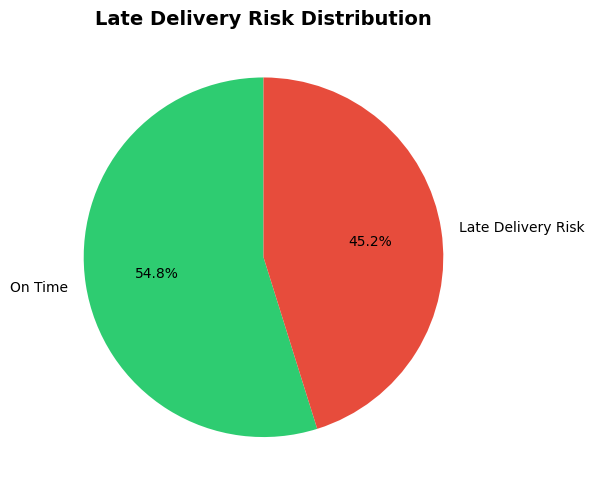

Chart saved!


In [9]:
labels = ['On Time', 'Late Delivery Risk']
sizes = df['Late_delivery_risk'].value_counts().values

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Late Delivery Risk Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '01_late_delivery_distribution.png'), dpi=150)
plt.show()
print("Chart saved!")

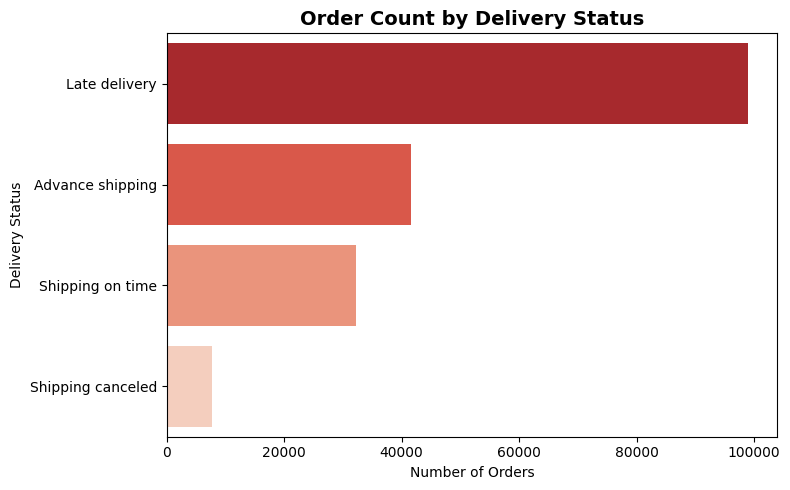

Chart saved!


In [10]:
status_counts = df['Delivery_Status'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='Reds_r')
plt.title('Order Count by Delivery Status', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Delivery Status')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '02_delivery_status_breakdown.png'), dpi=150)
plt.show()
print("Chart saved!")

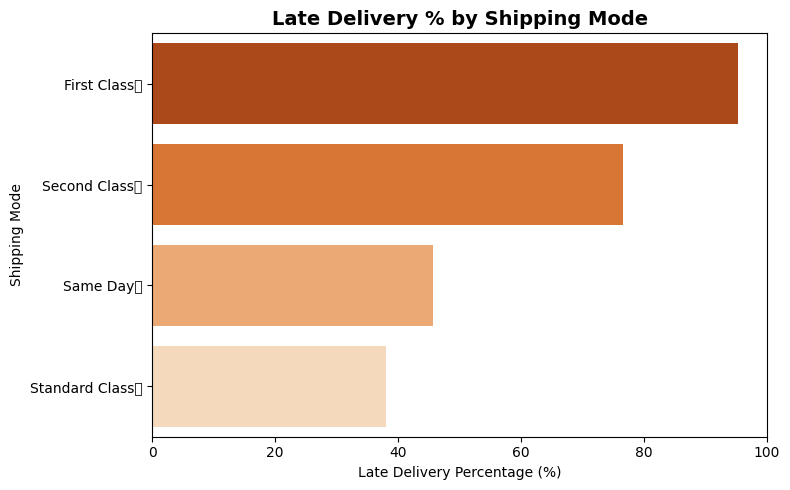

Chart saved!


In [11]:
shipping_late = df.groupby('Shipping_Mode')['Late_delivery_risk'].mean() * 100
shipping_late = shipping_late.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=shipping_late.values, y=shipping_late.index, palette='Oranges_r')
plt.title('Late Delivery % by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Late Delivery Percentage (%)')
plt.ylabel('Shipping Mode')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '03_shipping_mode_late_delivery.png'), dpi=150)
plt.show()
print("Chart saved!")

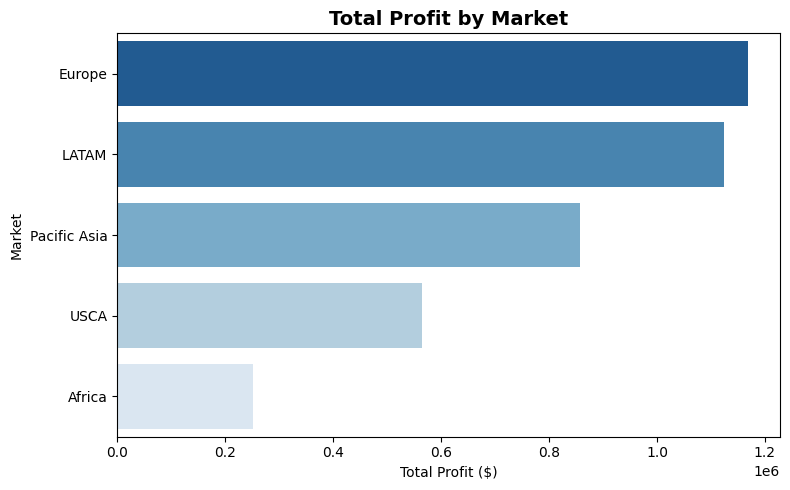

Chart saved!


In [12]:
market_profit = df.groupby('Market')['Order_Profit_Per_Order'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=market_profit.values, y=market_profit.index, palette='Blues_r')
plt.title('Total Profit by Market', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Market')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '04_profit_by_market.png'), dpi=150)
plt.show()
print("Chart saved!")

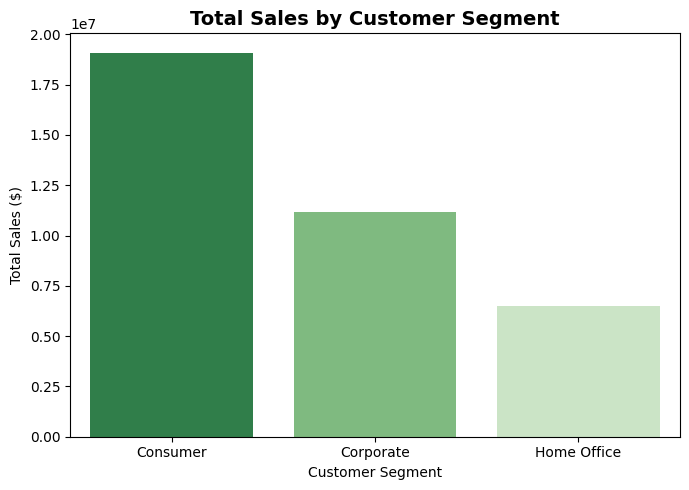

Chart saved!


In [13]:
segment_sales = df.groupby('Customer_Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette='Greens_r')
plt.title('Total Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '05_sales_by_segment.png'), dpi=150)
plt.show()
print("Chart saved!")

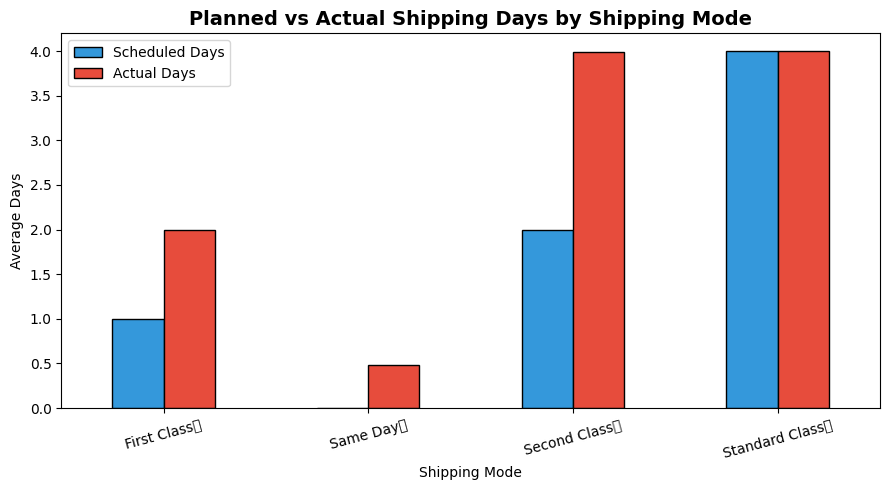

Chart saved!


In [14]:
shipping_days = df.groupby('Shipping_Mode')[['Days_for_shipment_scheduled', 'Days_for_shipping_real']].mean().round(2)

shipping_days.plot(kind='bar', figsize=(9, 5), color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Planned vs Actual Shipping Days by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Days')
plt.xticks(rotation=15)
plt.legend(['Scheduled Days', 'Actual Days'])
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '06_planned_vs_actual_shipping.png'), dpi=150)
plt.show()
print("Chart saved!")

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Selecting features that influence late delivery
features = ['Shipping_Mode', 'Days_for_shipment_scheduled', 
            'Order_Item_Quantity', 'Market', 'Customer_Segment']

target = 'Late_delivery_risk'

# Copying only required columns
ml_df = df[features + [target]].copy()

# Encoding categorical columns into numbers
le = LabelEncoder()
for col in ['Shipping_Mode', 'Market', 'Customer_Segment']:
    ml_df[col] = le.fit_transform(ml_df[col])

# Splitting into train and test sets (80/20)
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Features used:", features)

Training set size: (144415, 5)
Testing set size: (36104, 5)
Features used: ['Shipping_Mode', 'Days_for_shipment_scheduled', 'Order_Item_Quantity', 'Market', 'Customer_Segment']


In [16]:
# Starting with a simple Logistic Regression as baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 68.75 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.82      0.70     16307
           1       0.79      0.58      0.67     19797

    accuracy                           0.69     36104
   macro avg       0.70      0.70      0.69     36104
weighted avg       0.71      0.69      0.69     36104



In [17]:
# Now trying Random Forest which usually performs better on structured data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 69.1 %

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16307
           1       0.83      0.54      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.73      0.69      0.69     36104



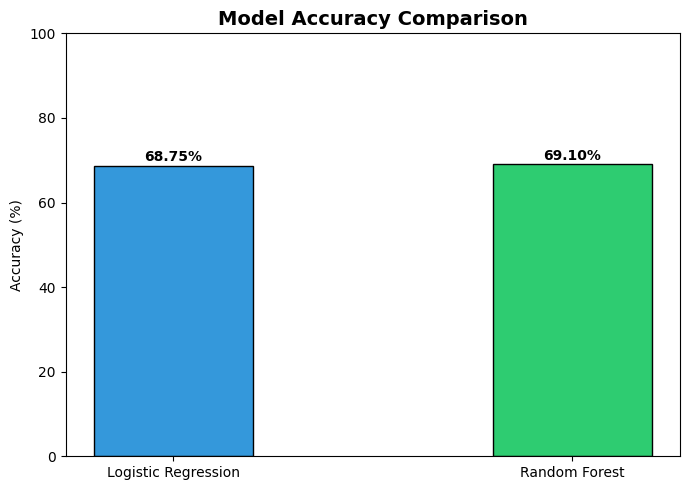

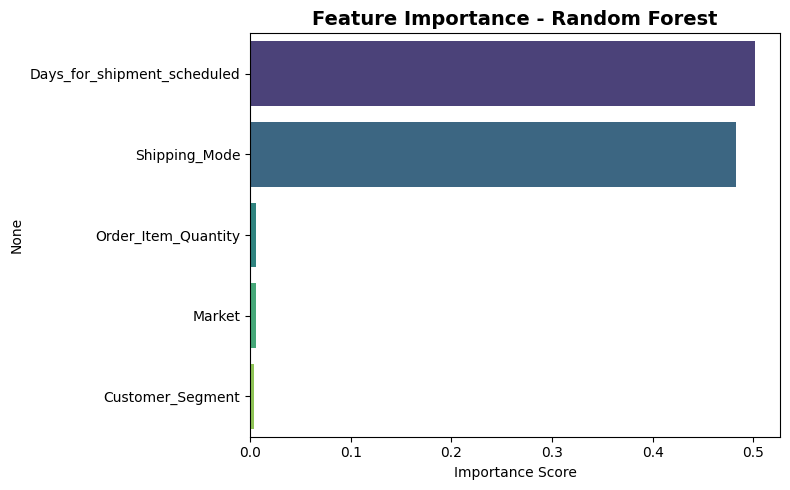

Winner: Random Forest with 69.1 % accuracy


In [18]:
# Comparing both models visually
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_accuracy * 100, rf_accuracy * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '07_model_comparison.png'), dpi=150)
plt.show()

# Feature importance from Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '08_feature_importance.png'), dpi=150)
plt.show()

print("Winner:", models[accuracies.index(max(accuracies))], "with", round(max(accuracies), 2), "% accuracy")

In [19]:
# Exporting clean data for Power BI dashboard
export_path = r"C:\Users\2000s\OneDrive\Documents\Projects\SCM End to End Project\05_PowerBI"

# Key columns needed for dashboard
powerbi_df = df[[
    'Type', 'Delivery_Status', 'Late_delivery_risk', 'Shipping_Mode',
    'Days_for_shipment_scheduled', 'Days_for_shipping_real',
    'Market', 'Order_Region', 'Customer_Segment',
    'Sales', 'Order_Profit_Per_Order', 'Order_Item_Quantity',
    'Product_Name', 'Category_Name', 'Order_date', 'Order_Status'
]].copy()

powerbi_df.to_csv(os.path.join(export_path, 'supply_chain_powerbi.csv'), index=False)
print("File exported successfully!")
print("Rows exported:", len(powerbi_df))
print("Saved to:", export_path)

File exported successfully!
Rows exported: 180519
Saved to: C:\Users\2000s\OneDrive\Documents\Projects\SCM End to End Project\05_PowerBI


In [20]:
# Installing XGBoost
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)

from xgboost import XGBClassifier

# Training XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

XGBoost Accuracy: 69.12 %

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16307
           1       0.84      0.54      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.74      0.69      0.69     36104



In [21]:
 # Building a stronger feature set using more columns from the dataset
ml_df2 = df.copy()

# Creating a new feature - difference between actual and scheduled days
ml_df2['delay_gap'] = ml_df2['Days_for_shipping_real'] - ml_df2['Days_for_shipment_scheduled']

# Selecting more meaningful features this time
features2 = [
    'Shipping_Mode', 'Days_for_shipment_scheduled', 'Days_for_shipping_real',
    'delay_gap', 'Order_Item_Quantity', 'Order_Item_Discount_Rate',
    'Order_Item_Profit_Ratio', 'Sales', 'Market', 'Customer_Segment'
]

target = 'Late_delivery_risk'

# Encoding categorical columns
le2 = LabelEncoder()
for col in ['Shipping_Mode', 'Market', 'Customer_Segment']:
    ml_df2[col] = le2.fit_transform(ml_df2[col])

X2 = ml_df2[features2]
y2 = ml_df2[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Training XGBoost with better features
xgb_model2 = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model2.fit(X2_train, y2_train)

xgb2_predictions = xgb_model2.predict(X2_test)
xgb2_accuracy = accuracy_score(y2_test, xgb2_predictions)

print("XGBoost Accuracy with better features:", round(xgb2_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y2_test, xgb2_predictions))

XGBoost Accuracy with better features: 97.49 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     16307
           1       0.96      1.00      0.98     19797

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.98      0.97      0.97     36104



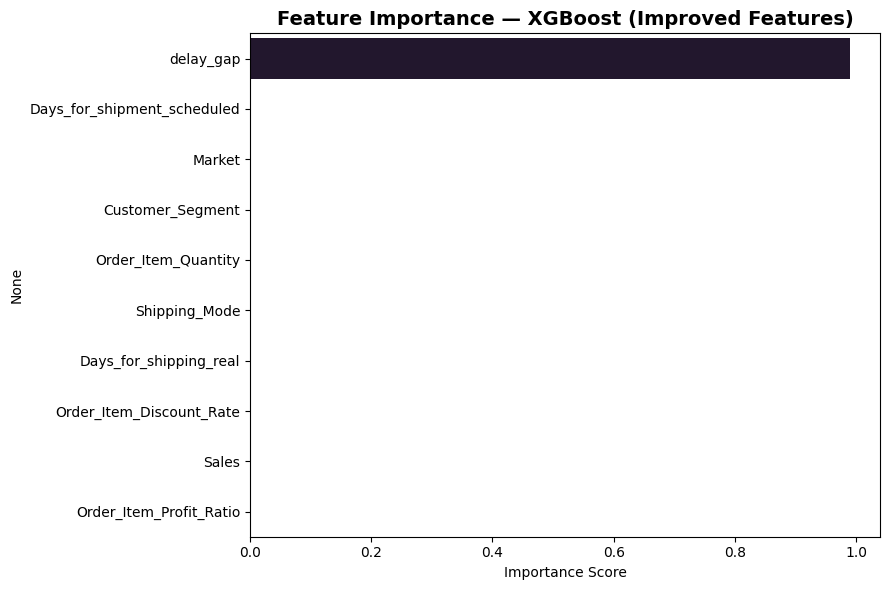

Top feature driving late delivery: delay_gap


In [22]:
xgb2_importance = pd.Series(xgb_model2.feature_importances_, index=features2).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=xgb2_importance.values, y=xgb2_importance.index, palette='rocket')
plt.title('Feature Importance — XGBoost (Improved Features)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, '11_xgboost_improved_features.png'), dpi=150)
plt.show()

print("Top feature driving late delivery:", xgb2_importance.index[0])

In [23]:
# Exporting clean data for Power BI dashboard
export_path = r"C:\Users\2000s\OneDrive\Documents\Projects\SCM End to End Project\05_PowerBI"

powerbi_df = df[[
    'Type', 'Delivery_Status', 'Late_delivery_risk', 'Shipping_Mode',
    'Days_for_shipment_scheduled', 'Days_for_shipping_real',
    'Market', 'Order_Region', 'Customer_Segment',
    'Sales', 'Order_Profit_Per_Order', 'Order_Item_Quantity',
    'Product_Name', 'Category_Name', 'Order_date', 'Order_Status'
]].copy()

powerbi_df.to_csv(os.path.join(export_path, 'supply_chain_powerbi.csv'), index=False)
print("File exported successfully!")
print("Rows exported:", len(powerbi_df))

File exported successfully!
Rows exported: 180519
